<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/Stage_1_ViT_Train_Loss_Plot_From_Out_Files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving model_20658_0.out to model_20658_0 (1).out
Saving model_20658_1.out to model_20658_1 (1).out
Saving model_20658_2.out to model_20658_2 (1).out
Saving model_20658_3.out to model_20658_3 (1).out


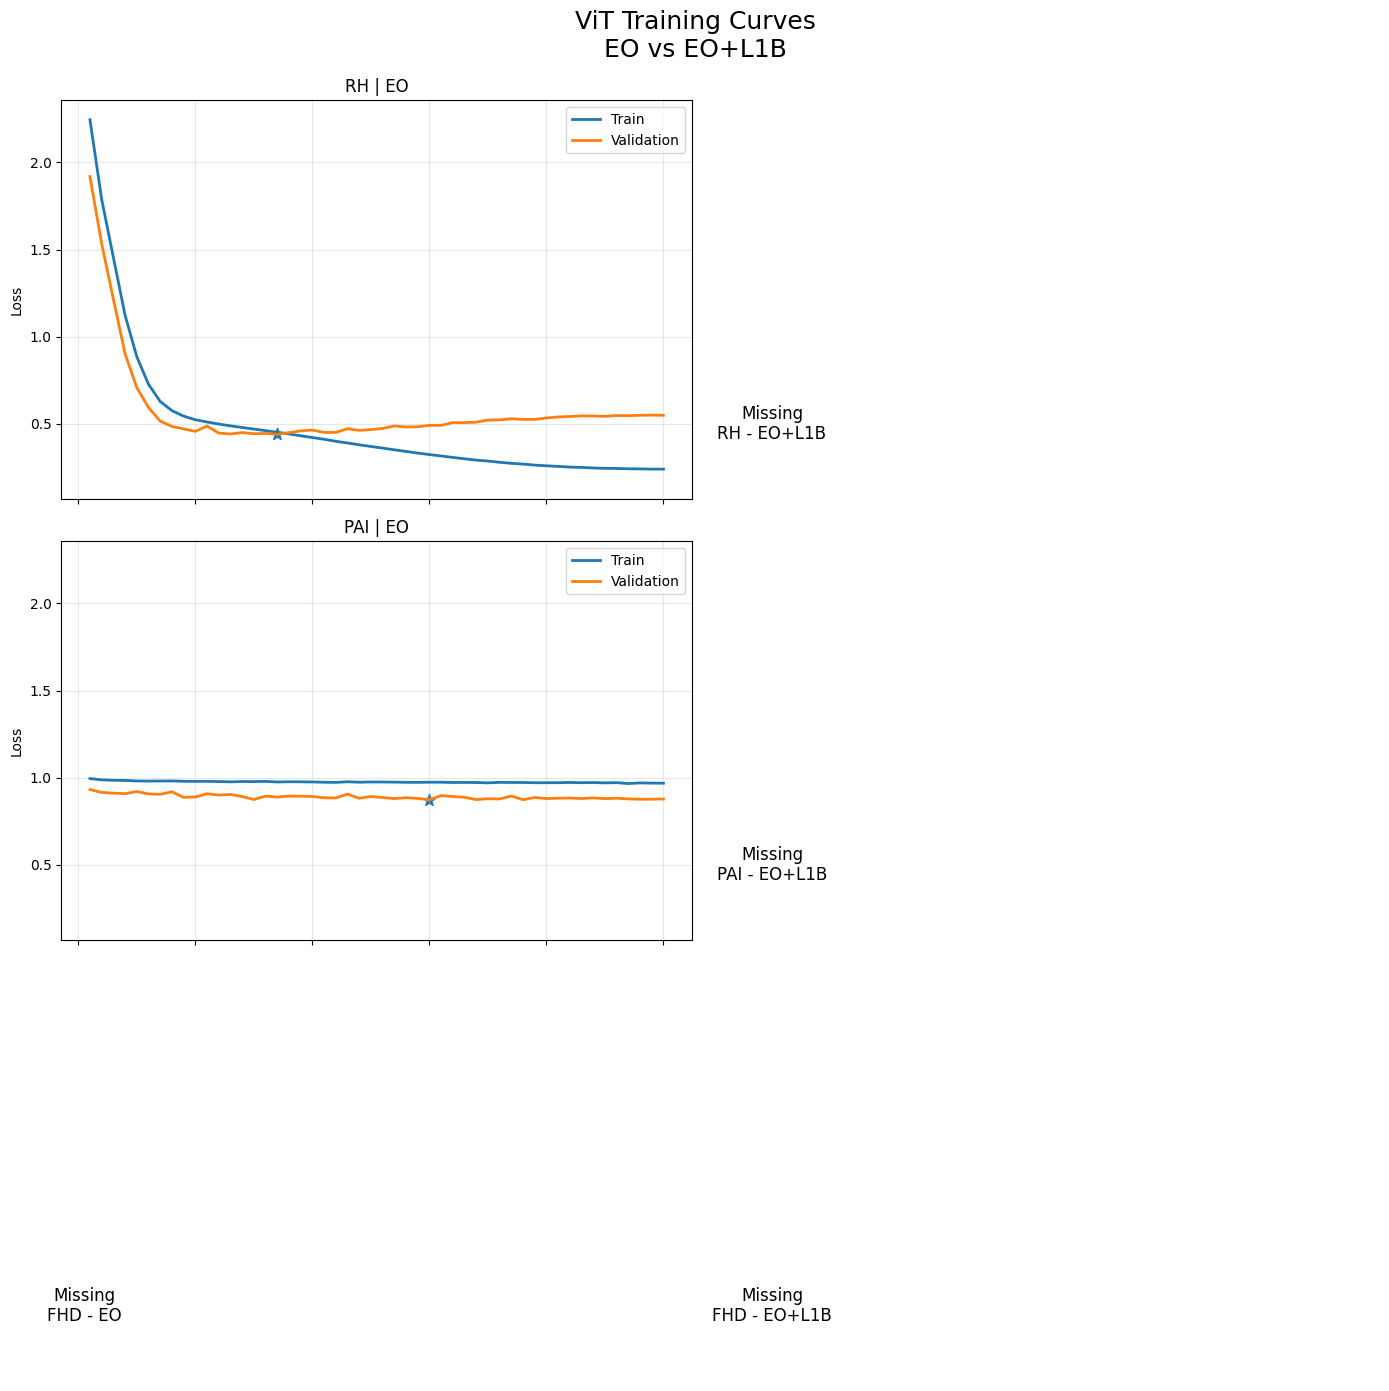

In [ ]:
# # ============================================================
# # ViT Training Loss Dashboard (3x2 Panel)
# # Upload all 6 .out files when prompted
# # ============================================================

# import re
# import io
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from google.colab import files

# # ------------------------------------------------------------
# # Upload files
# # ------------------------------------------------------------
# uploaded = files.upload()

# # ------------------------------------------------------------
# # Parse a single .out file
# # ------------------------------------------------------------
# def parse_log(text):

#     # Task
#     task_match = re.search(r"Task:\s*(\w+)", text)
#     task = task_match.group(1) if task_match else "Unknown"

#     # Modality
#     mod_match = re.search(r"Modalities:\s*(.+)", text)
#     modality_raw = mod_match.group(1).strip() if mod_match else "Unknown"

#     if "EO_only" in modality_raw:
#         modality = "EO"
#     elif "+" in modality_raw:
#         modality = "EO_plus_L1B"
#     else:
#         modality = modality_raw

#     epochs = []
#     train_losses = []
#     val_losses = []

#     pattern = (
#         r"Epoch\s+(\d+)\/\d+\s+\|\s+Train:\s+([0-9.]+)"
#         r"\s+\|\s+Val:\s+([0-9.]+)"
#     )

#     for m in re.finditer(pattern, text):
#         epochs.append(int(m.group(1)))
#         train_losses.append(float(m.group(2)))
#         val_losses.append(float(m.group(3)))

#     return {
#         "task": task,
#         "modality": modality,
#         "epochs": np.array(epochs),
#         "train": np.array(train_losses),
#         "val": np.array(val_losses),
#     }

# # ------------------------------------------------------------
# # Read all uploaded files
# # ------------------------------------------------------------
# runs = []

# for fname, content in uploaded.items():

#     try:
#         text = content.decode("utf-8", errors="ignore")
#     except:
#         text = str(content)

#     run = parse_log(text)
#     run["filename"] = fname

#     runs.append(run)

# # ------------------------------------------------------------
# # Determine common y-axis range
# # ------------------------------------------------------------
# all_losses = []

# for r in runs:
#     all_losses.extend(r["train"])
#     all_losses.extend(r["val"])

# ymin = min(all_losses) * 0.95
# ymax = max(all_losses) * 1.05

# # ------------------------------------------------------------
# # Desired panel order
# # ------------------------------------------------------------
# tasks = ["RH", "PAI", "FHD"]
# modalities = ["EO", "EO+L1B"]

# # Build lookup
# lookup = {}

# for r in runs:
#     lookup[(r["task"], r["modality"])] = r

# # ------------------------------------------------------------
# # Plot
# # ------------------------------------------------------------
# fig, axes = plt.subplots(
#     3,
#     2,
#     figsize=(14, 14),
#     sharex=True,
#     sharey=True
# )

# for row, task in enumerate(tasks):
#     for col, modality in enumerate(modalities):

#         ax = axes[row, col]

#         key = (task, modality)

#         if key not in lookup:
#             ax.text(
#                 0.5,
#                 0.5,
#                 f"Missing\n{task} - {modality}",
#                 ha="center",
#                 va="center",
#                 fontsize=12
#             )
#             ax.set_axis_off()
#             continue

#         run = lookup[key]

#         epochs = run["epochs"]
#         train_loss = run["train"]
#         val_loss = run["val"]

#         ax.plot(
#             epochs,
#             train_loss,
#             linewidth=2,
#             label="Train"
#         )

#         ax.plot(
#             epochs,
#             val_loss,
#             linewidth=2,
#             label="Validation"
#         )

#         # Best validation epoch
#         best_idx = np.argmin(val_loss)

#         ax.scatter(
#             epochs[best_idx],
#             val_loss[best_idx],
#             s=80,
#             marker="*"
#         )

#         ax.set_title(f"{task} | {modality}")

#         ax.grid(True, alpha=0.3)

#         ax.set_ylim(ymin, ymax)

#         if row == 2:
#             ax.set_xlabel("Epoch")

#         if col == 0:
#             ax.set_ylabel("Loss")

#         ax.legend()

# # ------------------------------------------------------------
# # Overall formatting
# # ------------------------------------------------------------
# plt.suptitle(
#     "ViT Training Curves\nEO vs EO+L1B",
#     fontsize=18,
#     y=0.99
# )

# plt.tight_layout()
# plt.show()

Saving variant_c_22196_0.out to variant_c_22196_0 (4).out
Saving variant_c_22196_1.out to variant_c_22196_1 (1).out
Saving variant_c_22196_2.out to variant_c_22196_2 (1).out
Saving variant_c_22196_3.out to variant_c_22196_3 (2).out
Saving variant_c_22196_4.out to variant_c_22196_4 (2).out
Saving variant_c_22196_5.out to variant_c_22196_5 (2).out

FILES DETECTED
Task=RH   | Modality=EO      | Epochs=50


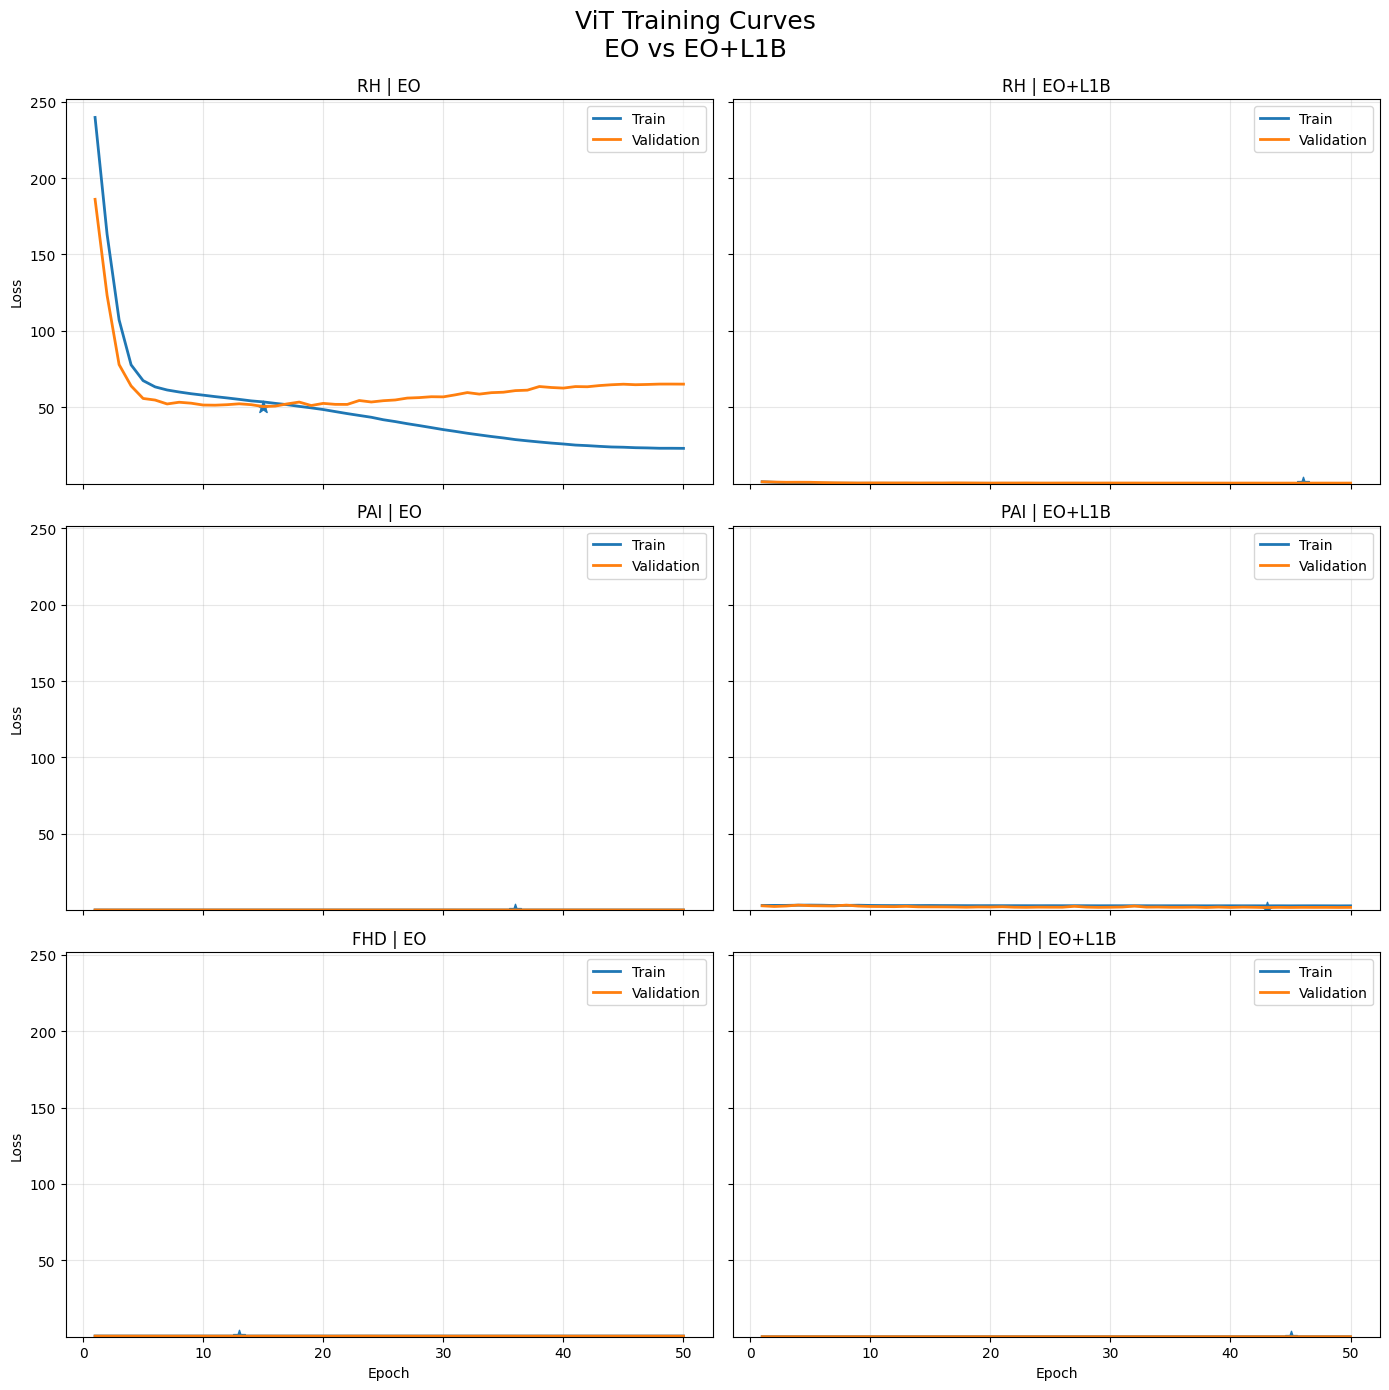

In [7]:
# ============================================================
# ViT Training Loss Dashboard (3x2 Panel)
# Upload all 6 .out files when prompted
# ============================================================

import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

# ------------------------------------------------------------
# Upload files
# ------------------------------------------------------------
uploaded = files.upload()

# ------------------------------------------------------------
# Parse a single .out file
# ------------------------------------------------------------
def parse_log(text):
    """
    Parse a Stage 1 Final training .out file
    """

    import re
    import numpy as np

    # --------------------------------------------------
    # Task
    # --------------------------------------------------
    task_match = re.search(r"Task:\s*(\w+)", text)
    task = task_match.group(1).strip() if task_match else "Unknown"

    # --------------------------------------------------
    # Modality
    # --------------------------------------------------
    mod_match = re.search(r"Modalities:\s*(.+)", text)

    if mod_match:
        modality_raw = mod_match.group(1).strip().lower()

        if "eo_only" in modality_raw:
            modality = "EO"

        elif "l1b" in modality_raw:
            modality = "EO+L1B"

        else:
            modality = modality_raw

    else:
        modality = "Unknown"

    # --------------------------------------------------
    # Epoch losses
    # --------------------------------------------------
    epochs = []
    train_losses = []
    val_losses = []

    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
    )

    for match in epoch_pattern.finditer(text):
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    return {
        "task": task,
        "modality": modality,
        "epochs": np.array(epochs),
        "train": np.array(train_losses),
        "val": np.array(val_losses),
    }

print("\n========================================")
print("FILES DETECTED")
print("========================================")

for r in runs:
    print(
        f"Task={r['task']:4s} | "
        f"Modality={r['modality']:7s} | "
        f"Epochs={len(r['epochs'])}"
    )

# ------------------------------------------------------------
# Read all uploaded files
# ------------------------------------------------------------
runs = []

for fname, content in uploaded.items():

    try:
        text = content.decode("utf-8", errors="ignore")
    except:
        text = str(content)

    run = parse_log(text)
    run["filename"] = fname

    runs.append(run)

# ------------------------------------------------------------
# Determine common y-axis range
# ------------------------------------------------------------
all_losses = []

for r in runs:
    all_losses.extend(r["train"])
    all_losses.extend(r["val"])

ymin = min(all_losses) * 0.95
ymax = max(all_losses) * 1.05

# ------------------------------------------------------------
# Desired panel order
# ------------------------------------------------------------
tasks = ["RH", "PAI", "FHD"]
modalities = ["EO", "EO+L1B"]

# Build lookup
lookup = {}

for r in runs:
    lookup[(r["task"], r["modality"])] = r

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

for row, task in enumerate(tasks):
    for col, modality in enumerate(modalities):

        ax = axes[row, col]

        key = (task, modality)

        if key not in lookup:
            ax.text(
                0.5,
                0.5,
                f"Missing\n{task} - {modality}",
                ha="center",
                va="center",
                fontsize=12
            )
            ax.set_axis_off()
            continue

        run = lookup[key]

        epochs = run["epochs"]
        train_loss = run["train"]
        val_loss = run["val"]

        ax.plot(
            epochs,
            train_loss,
            linewidth=2,
            label="Train"
        )

        ax.plot(
            epochs,
            val_loss,
            linewidth=2,
            label="Validation"
        )

        # Best validation epoch
        best_idx = np.argmin(val_loss)

        ax.scatter(
            epochs[best_idx],
            val_loss[best_idx],
            s=80,
            marker="*"
        )

        ax.set_title(f"{task} | {modality}")

        ax.grid(True, alpha=0.3)

        ax.set_ylim(ymin, ymax)

        if row == 2:
            ax.set_xlabel("Epoch")

        if col == 0:
            ax.set_ylabel("Loss")

        ax.legend()

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------
plt.suptitle(
    "ViT Training Curves\nEO vs EO+L1B",
    fontsize=18,
    y=0.99
)

plt.tight_layout()
plt.show()

Saving variant_c_22196_0.out to variant_c_22196_0 (5).out
Saving variant_c_22196_1.out to variant_c_22196_1 (2).out
Saving variant_c_22196_2.out to variant_c_22196_2 (2).out
Saving variant_c_22196_3.out to variant_c_22196_3 (3).out
Saving variant_c_22196_4.out to variant_c_22196_4 (3).out
Saving variant_c_22196_5.out to variant_c_22196_5 (3).out

FILES DETECTED
Task=RH   | Modality=EO      | Epochs=50
Task=RH   | Modality=EO+L1B  | Epochs=50
Task=PAI  | Modality=EO      | Epochs=50
Task=PAI  | Modality=EO+L1B  | Epochs=50
Task=FHD  | Modality=EO      | Epochs=50
Task=FHD  | Modality=EO+L1B  | Epochs=50


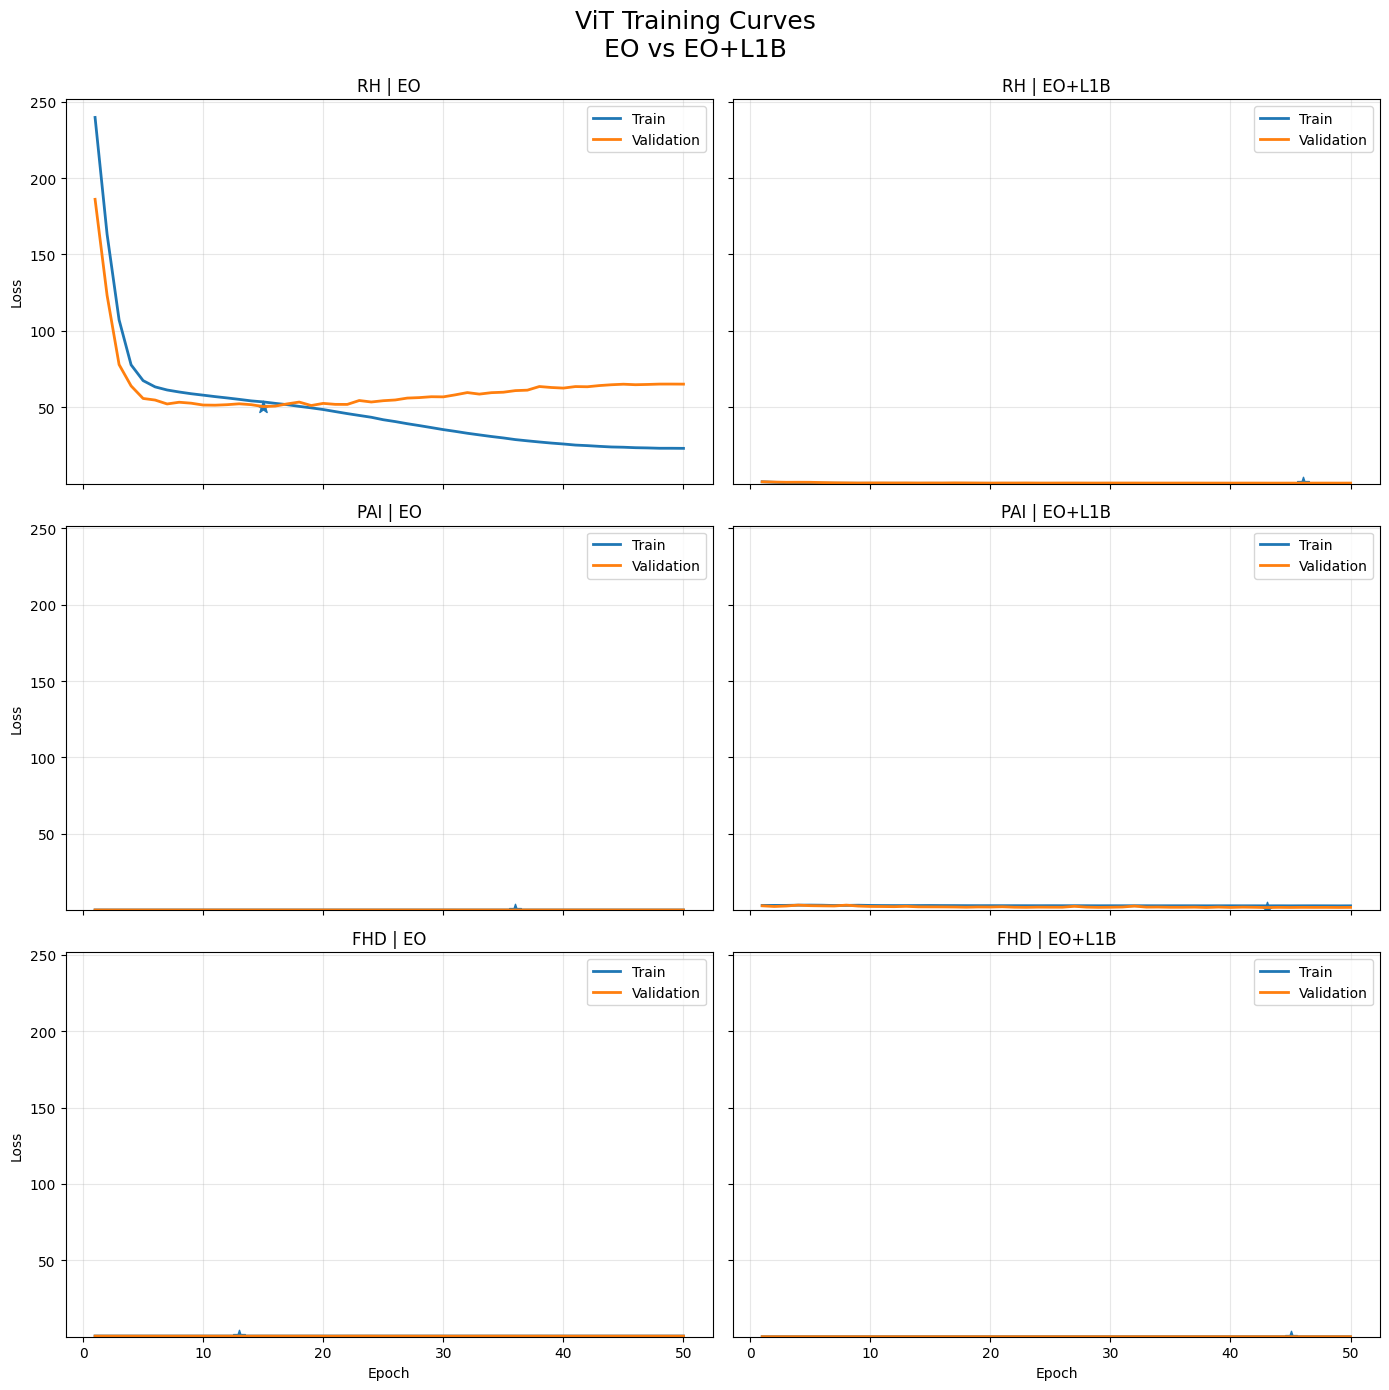

In [8]:
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload files
uploaded = files.upload()

# Parse function
def parse_log(text):
    import re
    import numpy as np

    task_match = re.search(r"Task:\s*(\w+)", text)
    task = task_match.group(1).strip() if task_match else "Unknown"

    mod_match = re.search(r"Modality:\s*(\S+)", text)
    if mod_match:
        modality_raw = mod_match.group(1).strip().lower()
        if modality_raw == "eo_only":
            modality = "EO"
        elif "eo_plus_l1b" in modality_raw or "l1b" in modality_raw:
            modality = "EO+L1B"
        else:
            modality = modality_raw
    else:
        modality = "Unknown"

    epochs, train_losses, val_losses = [], [], []
    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
    )
    for match in epoch_pattern.finditer(text):
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    return {
        "task": task,
        "modality": modality,
        "epochs": np.array(epochs),
        "train": np.array(train_losses),
        "val": np.array(val_losses),
    }

# Read all uploaded files
runs = []
for fname, content in uploaded.items():
    try:
        text = content.decode("utf-8", errors="ignore")
    except:
        text = str(content)
    run = parse_log(text)
    run["filename"] = fname
    runs.append(run)

# Print detected files
print("\n========================================")
print("FILES DETECTED")
print("========================================")
for r in runs:
    print(
        f"Task={r['task']:4s} | "
        f"Modality={r['modality']:7s} | "
        f"Epochs={len(r['epochs'])}"
    )

# # ============================================================
# # ViT Training Loss Dashboard (3x2 Panel)
# # Upload all 6 .out files when prompted
# # ============================================================

# import re
# import io
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from google.colab import files

# # ------------------------------------------------------------
# # Upload files
# # ------------------------------------------------------------
# uploaded = files.upload()

# # ------------------------------------------------------------
# # Parse a single .out file
# # ------------------------------------------------------------
# def parse_log(text):
#     import re
#     import numpy as np

#     # Task
#     task_match = re.search(r"Task:\s*(\w+)", text)
#     task = task_match.group(1).strip() if task_match else "Unknown"

#     # Modality
#     mod_match = re.search(r"Modality:\s*(\S+)", text)

#     if mod_match:
#         modality_raw = mod_match.group(1).strip().lower()

#         if modality_raw == "eo_only":
#             modality = "EO"
#         elif "eo_plus_l1b" in modality_raw or "l1b" in modality_raw:
#             modality = "EO+L1B"
#         else:
#             modality = modality_raw
#     else:
#         modality = "Unknown"

#     # Epoch losses
#     epochs = []
#     train_losses = []
#     val_losses = []

#     epoch_pattern = re.compile(
#         r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
#     )

#     for match in epoch_pattern.finditer(text):
#         epochs.append(int(match.group(1)))
#         train_losses.append(float(match.group(2)))
#         val_losses.append(float(match.group(3)))

#     return {
#         "task": task,
#         "modality": modality,
#         "epochs": np.array(epochs),
#         "train": np.array(train_losses),
#         "val": np.array(val_losses),
#     }

# print("\n========================================")
# print("FILES DETECTED")
# print("========================================")

# for r in runs:
#     print(
#         f"Task={r['task']:4s} | "
#         f"Modality={r['modality']:7s} | "
#         f"Epochs={len(r['epochs'])}"
#     )

# # # ------------------------------------------------------------
# # # Read all uploaded files
# # # ------------------------------------------------------------
# # runs = []

# # for fname, content in uploaded.items():

# #     try:
# #         text = content.decode("utf-8", errors="ignore")
# #     except:
# #         text = str(content)

# #     run = parse_log(text)
# #     run["filename"] = fname

# #     runs.append(run)

# # ------------------------------------------------------------
# # Read all uploaded files
# # ------------------------------------------------------------
# runs = []

# for fname, content in uploaded.items():

#     try:
#         text = content.decode("utf-8", errors="ignore")
#     except:
#         text = str(content)

#     run = parse_log(text)
#     run["filename"] = fname

#     runs.append(run)

# print("\n========================================")
# print("FILES DETECTED")
# print("========================================")

# for r in runs:
#     print(
#         f"Task={r['task']:4s} | "
#         f"Modality={r['modality']:7s} | "
#         f"Epochs={len(r['epochs'])}"
#    )

# ------------------------------------------------------------
# Determine common y-axis range
# ------------------------------------------------------------
all_losses = []

for r in runs:
    all_losses.extend(r["train"])
    all_losses.extend(r["val"])

ymin = min(all_losses) * 0.95
ymax = max(all_losses) * 1.05

# ------------------------------------------------------------
# Desired panel order
# ------------------------------------------------------------
tasks = ["RH", "PAI", "FHD"]
modalities = ["EO", "EO+L1B"]

# Build lookup
lookup = {}

for r in runs:
    lookup[(r["task"], r["modality"])] = r

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

for row, task in enumerate(tasks):
    for col, modality in enumerate(modalities):

        ax = axes[row, col]

        key = (task, modality)

        if key not in lookup:
            ax.text(
                0.5,
                0.5,
                f"Missing\n{task} - {modality}",
                ha="center",
                va="center",
                fontsize=12
            )
            ax.set_axis_off()
            continue

        run = lookup[key]

        epochs = run["epochs"]
        train_loss = run["train"]
        val_loss = run["val"]

        ax.plot(
            epochs,
            train_loss,
            linewidth=2,
            label="Train"
        )

        ax.plot(
            epochs,
            val_loss,
            linewidth=2,
            label="Validation"
        )

        # Best validation epoch
        best_idx = np.argmin(val_loss)

        ax.scatter(
            epochs[best_idx],
            val_loss[best_idx],
            s=80,
            marker="*"
        )

        ax.set_title(f"{task} | {modality}")

        ax.grid(True, alpha=0.3)

        ax.set_ylim(ymin, ymax)

        if row == 2:
            ax.set_xlabel("Epoch")

        if col == 0:
            ax.set_ylabel("Loss")

        ax.legend()

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------
plt.suptitle(
    "ViT Training Curves\nEO vs EO+L1B",
    fontsize=18,
    y=0.99
)

plt.tight_layout()
plt.show()

Saving variant_c_22196_0.out to variant_c_22196_0 (6).out
Saving variant_c_22196_1.out to variant_c_22196_1 (3).out
Saving variant_c_22196_2.out to variant_c_22196_2 (3).out
Saving variant_c_22196_3.out to variant_c_22196_3 (4).out
Saving variant_c_22196_4.out to variant_c_22196_4 (4).out
Saving variant_c_22196_5.out to variant_c_22196_5 (4).out

FILES DETECTED
Task=FHD  | Modality=EO      | Loss=MAE  | LR=0.0002   | Epochs=50
Task=FHD  | Modality=EO+L1B  | Loss=Huber0 | LR=0.0002   | Epochs=50
Task=PAI  | Modality=EO      | Loss=Huber0 | LR=0.0002   | Epochs=50
Task=PAI  | Modality=EO+L1B  | Loss=MSE  | LR=0.0005   | Epochs=50
Task=RH   | Modality=EO      | Loss=MSE  | LR=0.0002   | Epochs=50
Task=RH   | Modality=EO+L1B  | Loss=Huber0 | LR=0.0002   | Epochs=50


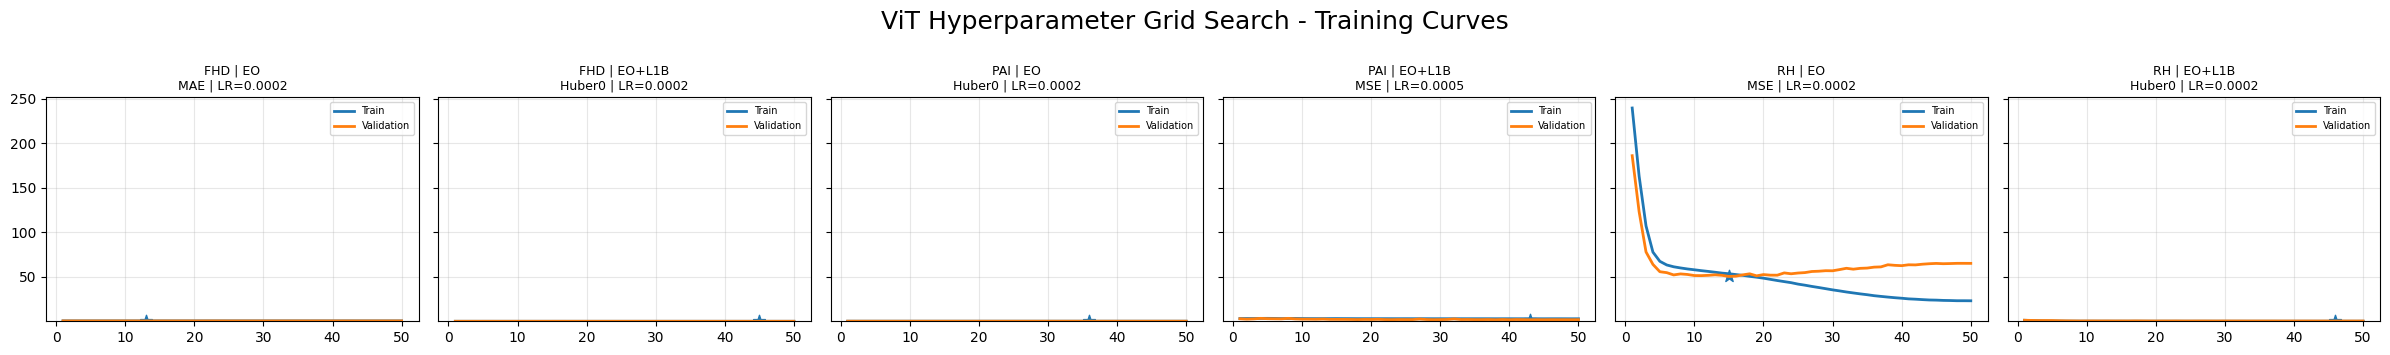

In [9]:
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------
# Upload files
# ------------------------------------------------------------
uploaded = files.upload()

# ------------------------------------------------------------
# Parse function
# ------------------------------------------------------------
def parse_log(text):
    task_match = re.search(r"Task:\s*(\w+)", text)
    task = task_match.group(1).strip() if task_match else "Unknown"

    mod_match = re.search(r"Modality:\s*(\S+)", text)
    if mod_match:
        modality_raw = mod_match.group(1).strip().lower()
        if modality_raw == "eo_only":
            modality = "EO"
        elif "eo_plus_l1b" in modality_raw or "l1b" in modality_raw:
            modality = "EO+L1B"
        else:
            modality = modality_raw
    else:
        modality = "Unknown"

    loss_match = re.search(r"Loss:\s*(\w+)", text)
    loss_fn = loss_match.group(1).strip() if loss_match else "Unknown"

    lr_match = re.search(r"LR:\s*([0-9.eE+-]+)", text)
    lr = float(lr_match.group(1)) if lr_match else None

    epochs, train_losses, val_losses = [], [], []
    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
    )
    for match in epoch_pattern.finditer(text):
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    return {
        "task": task,
        "modality": modality,
        "loss_fn": loss_fn,
        "lr": lr,
        "epochs": np.array(epochs),
        "train": np.array(train_losses),
        "val": np.array(val_losses),
    }

# ------------------------------------------------------------
# Read all uploaded files
# ------------------------------------------------------------
runs = []
for fname, content in uploaded.items():
    try:
        text = content.decode("utf-8", errors="ignore")
    except:
        text = str(content)
    run = parse_log(text)
    run["filename"] = fname
    runs.append(run)

# Sort by task, modality, loss_fn, lr for consistent ordering
runs.sort(key=lambda r: (r["task"], r["modality"], r["loss_fn"], r["lr"]))

print("\n========================================")
print("FILES DETECTED")
print("========================================")
for r in runs:
    print(
        f"Task={r['task']:4s} | "
        f"Modality={r['modality']:7s} | "
        f"Loss={r['loss_fn']:4s} | "
        f"LR={r['lr']:<8} | "
        f"Epochs={len(r['epochs'])}"
    )

# ------------------------------------------------------------
# Determine common y-axis range
# ------------------------------------------------------------
all_losses = []
for r in runs:
    all_losses.extend(r["train"])
    all_losses.extend(r["val"])

ymin = min(all_losses) * 0.95
ymax = max(all_losses) * 1.05

# ------------------------------------------------------------
# Plot grid - auto-size based on number of runs
# ------------------------------------------------------------
n_runs = len(runs)
n_cols = 6
n_rows = int(np.ceil(n_runs / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, run in enumerate(runs):
    ax = axes[i]

    epochs = run["epochs"]
    train_loss = run["train"]
    val_loss = run["val"]

    ax.plot(epochs, train_loss, linewidth=2, label="Train")
    ax.plot(epochs, val_loss, linewidth=2, label="Validation")

    if len(val_loss) > 0:
        best_idx = np.argmin(val_loss)
        ax.scatter(epochs[best_idx], val_loss[best_idx], s=80, marker="*")

    ax.set_title(
        f"{run['task']} | {run['modality']}\n{run['loss_fn']} | LR={run['lr']}",
        fontsize=9
    )
    ax.grid(True, alpha=0.3)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(n_runs, len(axes)):
    axes[j].set_axis_off()

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------
plt.suptitle("ViT Hyperparameter Grid Search - Training Curves", fontsize=18, y=1.0)
plt.tight_layout()
plt.show()

Saving variant_c_22196_0.out to variant_c_22196_0.out
Saving variant_c_22196_1.out to variant_c_22196_1.out
Saving variant_c_22196_2.out to variant_c_22196_2.out
Saving variant_c_22196_3.out to variant_c_22196_3.out
Saving variant_c_22196_4.out to variant_c_22196_4.out
Saving variant_c_22196_5.out to variant_c_22196_5.out

FILES DETECTED
Task=FHD  | Modality=EO      | Loss=MAE  | LR=0.0002   | Epochs=50 | Drop/epoch=0.11%
Task=FHD  | Modality=EO+L1B  | Loss=Huber0 | LR=0.0002   | Epochs=50 | Drop/epoch=0.11%
Task=PAI  | Modality=EO      | Loss=Huber0 | LR=0.0002   | Epochs=50 | Drop/epoch=0.12%
Task=PAI  | Modality=EO+L1B  | Loss=MSE  | LR=0.0005   | Epochs=50 | Drop/epoch=0.74%
Task=RH   | Modality=EO      | Loss=MSE  | LR=0.0002   | Epochs=50 | Drop/epoch=1.33%
Task=RH   | Modality=EO+L1B  | Loss=Huber0 | LR=0.0002   | Epochs=50 | Drop/epoch=1.47%


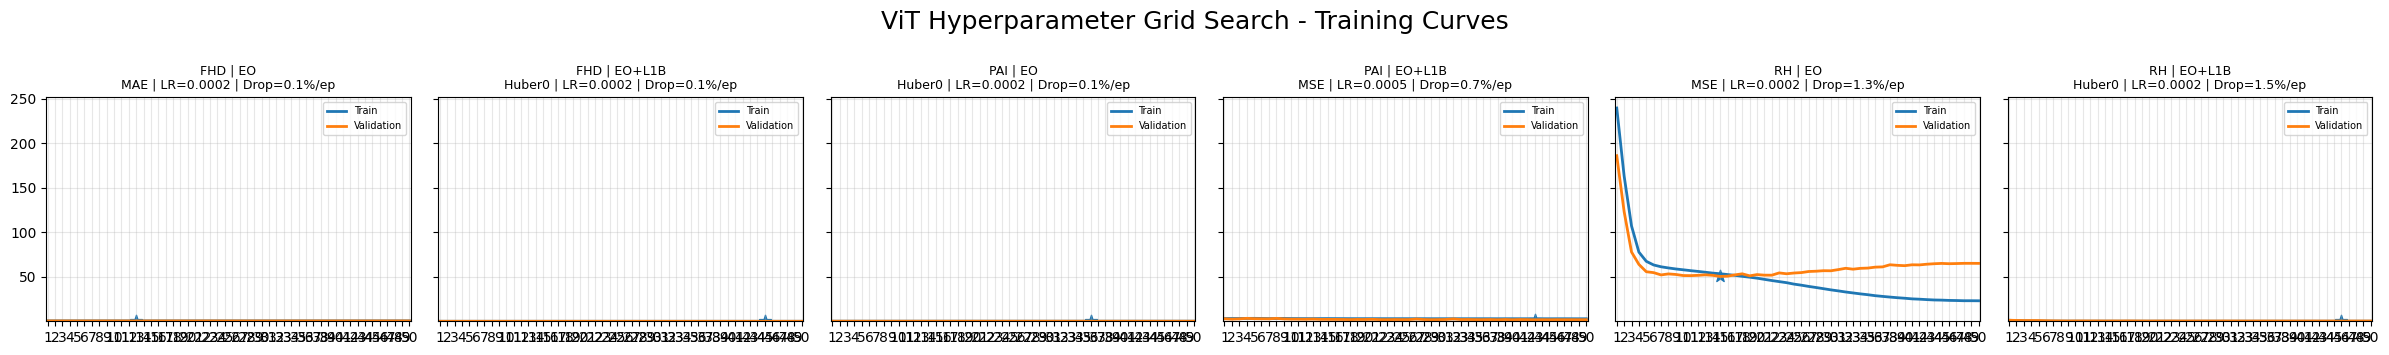


RANKED BY LEARNING EFFICIENCY (Drop %/epoch)
Task Modality   Loss     LR  Final Val Loss  Drop %/epoch  Total Drop %
  RH   EO+L1B Huber0 0.0002          0.3321      1.466350     71.851161
  RH       EO    MSE 0.0002         65.0995      1.326783     65.012345
 PAI   EO+L1B    MSE 0.0005          1.8290      0.735784     36.053423
 PAI       EO Huber0 0.0002          0.1300      0.118308      5.797101
 FHD       EO    MAE 0.0002          0.4289      0.109000      5.340984
 FHD   EO+L1B Huber0 0.0002          0.0455      0.106293      5.208333


In [1]:
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------
# Upload files
# ------------------------------------------------------------
uploaded = files.upload()

# ------------------------------------------------------------
# Parse function
# ------------------------------------------------------------
def parse_log(text):
    task_match = re.search(r"Task:\s*(\w+)", text)
    task = task_match.group(1).strip() if task_match else "Unknown"

    mod_match = re.search(r"Modality:\s*(\S+)", text)
    if mod_match:
        modality_raw = mod_match.group(1).strip().lower()
        if modality_raw == "eo_only":
            modality = "EO"
        elif "eo_plus_l1b" in modality_raw or "l1b" in modality_raw:
            modality = "EO+L1B"
        else:
            modality = modality_raw
    else:
        modality = "Unknown"

    loss_match = re.search(r"Loss:\s*(\w+)", text)
    loss_fn = loss_match.group(1).strip() if loss_match else "Unknown"

    lr_match = re.search(r"LR:\s*([0-9.eE+-]+)", text)
    lr = float(lr_match.group(1)) if lr_match else None

    epochs, train_losses, val_losses = [], [], []
    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
    )
    for match in epoch_pattern.finditer(text):
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    return {
        "task": task,
        "modality": modality,
        "loss_fn": loss_fn,
        "lr": lr,
        "epochs": np.array(epochs),
        "train": np.array(train_losses),
        "val": np.array(val_losses),
    }

# ------------------------------------------------------------
# Read all uploaded files
# ------------------------------------------------------------
runs = []
for fname, content in uploaded.items():
    try:
        text = content.decode("utf-8", errors="ignore")
    except:
        text = str(content)
    run = parse_log(text)
    run["filename"] = fname

    # --------------------------------------------------
    # Drop rate: avg % decrease in val loss per epoch
    # (first epoch -> last epoch)
    # --------------------------------------------------
    val = run["val"]
    if len(val) >= 2 and val[0] != 0:
        n_steps = len(val) - 1
        total_drop_pct = (val[0] - val[-1]) / val[0] * 100
        drop_rate_per_epoch = total_drop_pct / n_steps
    else:
        total_drop_pct = np.nan
        drop_rate_per_epoch = np.nan

    run["total_drop_pct"] = total_drop_pct
    run["drop_rate_per_epoch"] = drop_rate_per_epoch

    runs.append(run)

# Sort by task, modality, loss_fn, lr for consistent ordering
runs.sort(key=lambda r: (r["task"], r["modality"], r["loss_fn"], r["lr"]))

print("\n========================================")
print("FILES DETECTED")
print("========================================")
for r in runs:
    print(
        f"Task={r['task']:4s} | "
        f"Modality={r['modality']:7s} | "
        f"Loss={r['loss_fn']:4s} | "
        f"LR={r['lr']:<8} | "
        f"Epochs={len(r['epochs'])} | "
        f"Drop/epoch={r['drop_rate_per_epoch']:.2f}%"
    )

# ------------------------------------------------------------
# Determine common y-axis range
# ------------------------------------------------------------
all_losses = []
for r in runs:
    all_losses.extend(r["train"])
    all_losses.extend(r["val"])

ymin = min(all_losses) * 0.95
ymax = max(all_losses) * 1.05

# ------------------------------------------------------------
# Plot grid - auto-size based on number of runs
# ------------------------------------------------------------
n_runs = len(runs)
n_cols = 6
n_rows = int(np.ceil(n_runs / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharex=False,   # dynamic x-axis per panel
    sharey=True
)

axes = axes.flatten()

for i, run in enumerate(runs):
    ax = axes[i]

    epochs = run["epochs"]
    train_loss = run["train"]
    val_loss = run["val"]

    ax.plot(epochs, train_loss, linewidth=2, label="Train")
    ax.plot(epochs, val_loss, linewidth=2, label="Validation")

    if len(val_loss) > 0:
        best_idx = np.argmin(val_loss)
        ax.scatter(epochs[best_idx], val_loss[best_idx], s=80, marker="*")

    # Dynamic x-axis: tight to this run's epoch range
    if len(epochs) > 0:
        ax.set_xlim(epochs.min() - 0.2, epochs.max() + 0.2)
        ax.set_xticks(epochs)

    drop_str = (
        f"{run['drop_rate_per_epoch']:.1f}%/ep"
        if not np.isnan(run['drop_rate_per_epoch'])
        else "n/a"
    )

    ax.set_title(
        f"{run['task']} | {run['modality']}\n"
        f"{run['loss_fn']} | LR={run['lr']} | Drop={drop_str}",
        fontsize=9
    )
    ax.grid(True, alpha=0.3)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(n_runs, len(axes)):
    axes[j].set_axis_off()

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------
plt.suptitle("ViT Hyperparameter Grid Search - Training Curves", fontsize=18, y=1.0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary table sorted by best (steepest) drop rate
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Task": r["task"],
        "Modality": r["modality"],
        "Loss": r["loss_fn"],
        "LR": r["lr"],
        "Final Val Loss": r["val"][-1] if len(r["val"]) else np.nan,
        "Drop %/epoch": r["drop_rate_per_epoch"],
        "Total Drop %": r["total_drop_pct"],
    }
    for r in runs
]).sort_values("Drop %/epoch", ascending=False)

print("\n========================================")
print("RANKED BY LEARNING EFFICIENCY (Drop %/epoch)")
print("========================================")
print(summary_df.to_string(index=False))

Saving variant_c_22196_0.out to variant_c_22196_0 (7).out
Saving variant_c_22196_1.out to variant_c_22196_1 (4).out
Saving variant_c_22196_2.out to variant_c_22196_2 (4).out
Saving variant_c_22196_3.out to variant_c_22196_3 (5).out
Saving variant_c_22196_4.out to variant_c_22196_4 (5).out
Saving variant_c_22196_5.out to variant_c_22196_5 (5).out

FILES DETECTED
Task=FHD  | Modality=EO      | Loss=MAE  | LR=0.0002   | Epochs=50 | Drop/epoch=0.11%
Task=FHD  | Modality=EO+L1B  | Loss=Huber0 | LR=0.0002   | Epochs=50 | Drop/epoch=0.11%
Task=PAI  | Modality=EO      | Loss=Huber0 | LR=0.0002   | Epochs=50 | Drop/epoch=0.12%
Task=PAI  | Modality=EO+L1B  | Loss=MSE  | LR=0.0005   | Epochs=50 | Drop/epoch=0.74%
Task=RH   | Modality=EO      | Loss=MSE  | LR=0.0002   | Epochs=50 | Drop/epoch=1.33%
Task=RH   | Modality=EO+L1B  | Loss=Huber0 | LR=0.0002   | Epochs=50 | Drop/epoch=1.47%


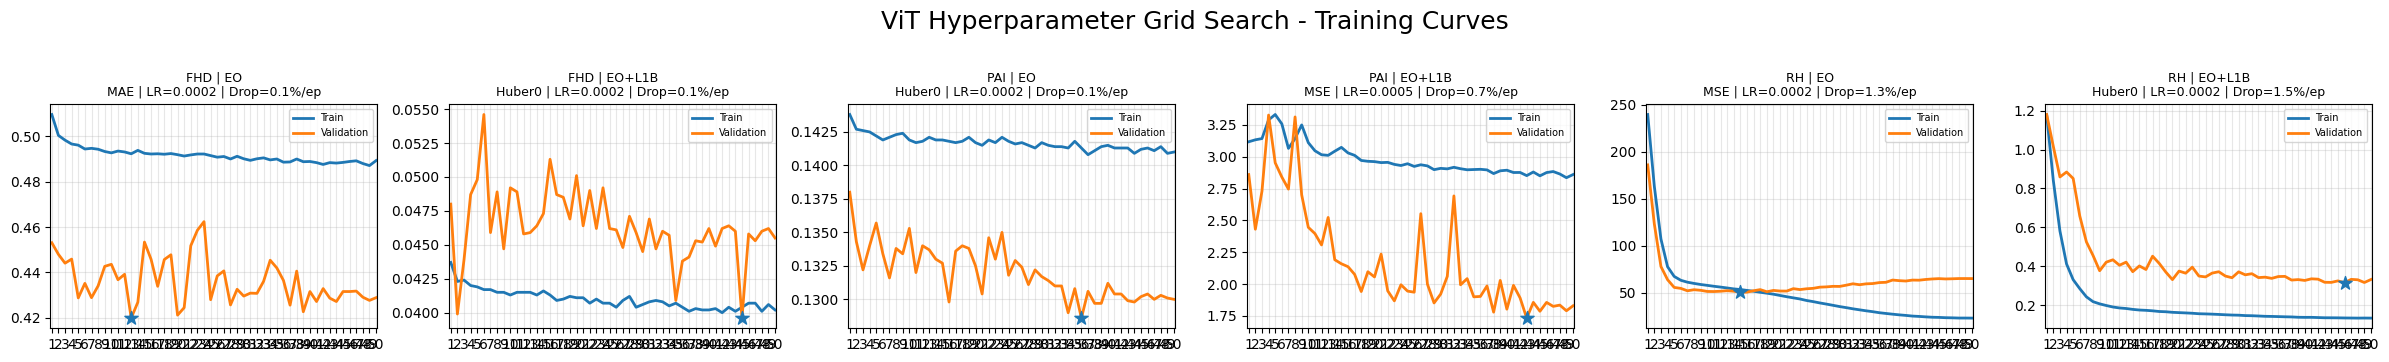


RANKED BY LEARNING EFFICIENCY (Drop %/epoch)
Task Modality   Loss     LR  Final Val Loss  Drop %/epoch  Total Drop %
  RH   EO+L1B Huber0 0.0002          0.3321      1.466350     71.851161
  RH       EO    MSE 0.0002         65.0995      1.326783     65.012345
 PAI   EO+L1B    MSE 0.0005          1.8290      0.735784     36.053423
 PAI       EO Huber0 0.0002          0.1300      0.118308      5.797101
 FHD       EO    MAE 0.0002          0.4289      0.109000      5.340984
 FHD   EO+L1B Huber0 0.0002          0.0455      0.106293      5.208333


In [11]:
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------
# Upload files
# ------------------------------------------------------------
uploaded = files.upload()

# ------------------------------------------------------------
# Parse function
# ------------------------------------------------------------
def parse_log(text):
    task_match = re.search(r"Task:\s*(\w+)", text)
    task = task_match.group(1).strip() if task_match else "Unknown"

    mod_match = re.search(r"Modality:\s*(\S+)", text)
    if mod_match:
        modality_raw = mod_match.group(1).strip().lower()
        if modality_raw == "eo_only":
            modality = "EO"
        elif "eo_plus_l1b" in modality_raw or "l1b" in modality_raw:
            modality = "EO+L1B"
        else:
            modality = modality_raw
    else:
        modality = "Unknown"

    loss_match = re.search(r"Loss:\s*(\w+)", text)
    loss_fn = loss_match.group(1).strip() if loss_match else "Unknown"

    lr_match = re.search(r"LR:\s*([0-9.eE+-]+)", text)
    lr = float(lr_match.group(1)) if lr_match else None

    epochs, train_losses, val_losses = [], [], []

    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
    )

    for match in epoch_pattern.finditer(text):
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    return {
        "task": task,
        "modality": modality,
        "loss_fn": loss_fn,
        "lr": lr,
        "epochs": np.array(epochs),
        "train": np.array(train_losses),
        "val": np.array(val_losses),
    }

# ------------------------------------------------------------
# Read all uploaded files
# ------------------------------------------------------------
runs = []

for fname, content in uploaded.items():
    try:
        text = content.decode("utf-8", errors="ignore")
    except:
        text = str(content)

    run = parse_log(text)
    run["filename"] = fname

    # --------------------------------------------------
    # Drop rate: avg % decrease in val loss per epoch
    # --------------------------------------------------
    val = run["val"]

    if len(val) >= 2 and val[0] != 0:
        n_steps = len(val) - 1
        total_drop_pct = (val[0] - val[-1]) / val[0] * 100
        drop_rate_per_epoch = total_drop_pct / n_steps
    else:
        total_drop_pct = np.nan
        drop_rate_per_epoch = np.nan

    run["total_drop_pct"] = total_drop_pct
    run["drop_rate_per_epoch"] = drop_rate_per_epoch

    runs.append(run)

# ------------------------------------------------------------
# Sort runs for consistent display
# ------------------------------------------------------------
runs.sort(
    key=lambda r: (
        r["task"],
        r["modality"],
        r["loss_fn"],
        r["lr"]
    )
)

print("\n========================================")
print("FILES DETECTED")
print("========================================")

for r in runs:
    print(
        f"Task={r['task']:4s} | "
        f"Modality={r['modality']:7s} | "
        f"Loss={r['loss_fn']:4s} | "
        f"LR={r['lr']:<8} | "
        f"Epochs={len(r['epochs'])} | "
        f"Drop/epoch={r['drop_rate_per_epoch']:.2f}%"
    )

# ------------------------------------------------------------
# Plot grid
# ------------------------------------------------------------
n_runs = len(runs)
n_cols = 6
n_rows = int(np.ceil(n_runs / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharex=False,
    sharey=False
)

# Handle single subplot case
if n_runs == 1:
    axes = np.array([axes])

axes = axes.flatten()

for i, run in enumerate(runs):

    ax = axes[i]

    epochs = run["epochs"]
    train_loss = run["train"]
    val_loss = run["val"]

    # Plot curves
    ax.plot(
        epochs,
        train_loss,
        linewidth=2,
        label="Train"
    )

    ax.plot(
        epochs,
        val_loss,
        linewidth=2,
        label="Validation"
    )

    # Best validation point
    if len(val_loss) > 0:
        best_idx = np.argmin(val_loss)

        ax.scatter(
            epochs[best_idx],
            val_loss[best_idx],
            s=100,
            marker="*",
            zorder=5
        )

    # --------------------------------------------------
    # Dynamic x-axis
    # --------------------------------------------------
    if len(epochs) > 0:
        ax.set_xlim(
            epochs.min() - 0.2,
            epochs.max() + 0.2
        )
        ax.set_xticks(epochs)

    # --------------------------------------------------
    # Dynamic y-axis (PER FILE)
    # --------------------------------------------------
    losses = np.concatenate([train_loss, val_loss])

    if len(losses) > 0:

        y_min = losses.min()
        y_max = losses.max()

        padding = (y_max - y_min) * 0.05

        # Handle flat curves
        if padding == 0:
            padding = max(abs(y_max) * 0.05, 0.001)

        ax.set_ylim(
            y_min - padding,
            y_max + padding
        )

    drop_str = (
        f"{run['drop_rate_per_epoch']:.1f}%/ep"
        if not np.isnan(run['drop_rate_per_epoch'])
        else "n/a"
    )

    ax.set_title(
        f"{run['task']} | {run['modality']}\n"
        f"{run['loss_fn']} | LR={run['lr']} | Drop={drop_str}",
        fontsize=9
    )

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

# ------------------------------------------------------------
# Hide unused subplots
# ------------------------------------------------------------
for j in range(n_runs, len(axes)):
    axes[j].set_axis_off()

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------
plt.suptitle(
    "ViT Hyperparameter Grid Search - Training Curves",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Task": r["task"],
        "Modality": r["modality"],
        "Loss": r["loss_fn"],
        "LR": r["lr"],
        "Final Val Loss": (
            r["val"][-1]
            if len(r["val"])
            else np.nan
        ),
        "Drop %/epoch": r["drop_rate_per_epoch"],
        "Total Drop %": r["total_drop_pct"],
    }
    for r in runs
]).sort_values(
    "Drop %/epoch",
    ascending=False
)

print("\n========================================")
print("RANKED BY LEARNING EFFICIENCY (Drop %/epoch)")
print("========================================")
print(summary_df.to_string(index=False))